# Vote Average Prediction

Im Diesem Dokument versuchen wir das Durchschnittliche Filmergebniss zu von Nutzervotes in der tmdb zu berechnen. 

Hierbei fixen wir noch eine sache die wir im Profitabilitätspredicting nicht gemacht haben. Die TMDB gibt uns nicht mit was für ein Typ von der Untersuchte eintrag ist. Somit haben wir in unserem Klustering auch Serien berücksichtigt, was aber auf grund der kleine des enddatensatzes eher positiv war.

Beginnen wir mit einem Massenimport an allem was in diesem Dokument gebraucht wird.

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter
import kagglehub
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt





A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\traitlets\config\application.py", lin

AttributeError: _ARRAY_API not found

c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\laure\.cache\kagglehub\datasets\ashirwadsangwan\imdb-dataset\versions\839


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


# 01 - Data Peparation

Import des IMDB Datensatzes und reduktion nur auf Filme

In [ ]:
# Wir laden hier den IMDB-Datensatz von Kaggle herunter im gegensatz zum TMDB-Datensatz, ist uns die Version des Datensatzes egal, da wir hiermit nur den TMDB-Datensatz vergleichen und reduzieren wollen.
path = kagglehub.dataset_download("ashirwadsangwan/imdb-dataset")

print("Path to dataset files:", path)
df = pd.read_csv(path + "/title.basics.tsv", sep="\t", low_memory=False)movie"]ing the original DataFrame

In [ ]:
from kagglehub import KaggleDatasetAdapter

# Load the dataset using KaggleHub
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/518",
    "TMDB_movie_dataset_v11.csv",)

# Drop unnecessary columns
df_drop_colums = df.drop(columns=['id', 'status', 'backdrop_path', 'poster_path', 'homepage'])
df_drop_colums.columns
del df # Free up memory by deleting the original  

,title,vote_average,vote_count,release_date,revenue,runtime,adult,budget,imdb_id,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,Inception,8.364,34495,2010-07-15,825532764,148,False,160000000,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,Interstellar,8.417,32571,2014-11-05,701729206,169,False,165000000,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.241,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,The Dark Knight,8.512,30619,2008-07-16,1004558444,152,False,185000000,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,Avatar,7.573,29815,2009-12-15,2923706026,162,False,237000000,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,The Avengers,7.710,29166,2012-04-25,1518815515,143,False,220000000,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [4]:
# Merge the dataframes on IMDb ID
merged_df = df_drop_colums.merge(
    df_only_movies,
    left_on='imdb_id',
    right_on='tconst',
    how='inner'
)

# Display the first few rows and basic information about the merged dataset
print("Shape of merged dataset:", merged_df.shape)
merged_df.head()

del df_only_movies  # Free up memory by deleting the filtered DataFrame
del df_drop_colums  # Free up memory by deleting the cleaned DataFrame

Shape of merged dataset: (337380, 28)


In [ ]:
# Filter merged_df for movies with vote_count >= 10
filtered_df = merged_df[merged_df['vote_count'] >= 10]

# Remove duplicates based on first occurrence.
filtered_df = filtered_df.drop_duplicates(keep='first')


# Display basic information about the filtered dataset
print("Shape of filtered dataset:", filtered_df.shape)
filtered_df.head()

Shape of filtered dataset: (62056, 28)


,title,vote_average,vote_count,release_date,revenue,runtime,adult,budget,imdb_id,original_language,...,keywords,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres_y
0,Inception,8.364,34495,2010-07-15,825532764,148,False,160000000,tt1375666,en,...,"rescue, mission, dream, airplane, paris, franc...",tt1375666,movie,Inception,Inception,0,2010,\N,148,"Action,Adventure,Sci-Fi"
1,Interstellar,8.417,32571,2014-11-05,701729206,169,False,165000000,tt0816692,en,...,"rescue, future, spacecraft, race against time,...",tt0816692,movie,Interstellar,Interstellar,0,2014,\N,169,"Adventure,Drama,Sci-Fi"
2,The Dark Knight,8.512,30619,2008-07-16,1004558444,152,False,185000000,tt0468569,en,...,"joker, sadism, chaos, secret identity, crime f...",tt0468569,movie,The Dark Knight,The Dark Knight,0,2008,\N,152,"Action,Crime,Drama"
3,Avatar,7.573,29815,2009-12-15,2923706026,162,False,237000000,tt0499549,en,...,"future, society, culture clash, space travel, ...",tt0499549,movie,Avatar,Avatar,0,2009,\N,162,"Action,Adventure,Fantasy"
4,The Avengers,7.710,29166,2012-04-25,1518815515,143,False,220000000,tt0848228,en,...,"new york city, superhero, shield, based on com...",tt0848228,movie,The Avengers,The Avengers,0,2012,\N,143,"Action,Sci-Fi"


In [6]:
# Create a copy to avoid modifying the original dataframe
df_encoded = filtered_df.copy()

# Function to split string-based lists into actual lists
def split_list_string(x):
    if isinstance(x, str):
        # Remove common separators and split
        return [item.strip() for item in x.split(',')]
    return []

# Clean feature names by removing special characters
def clean_feature_name(name):
    return name.replace('[', '').replace(']', '').replace('<', '_').replace('>', '_')

# Columns to encode
columns_to_encode = [
    'genres_x', 
    'production_countries', 
    'spoken_languages', 
    'original_language',
    'production_companies'  # Added production_companies to the list
]

# Create MultiLabelBinarizer for each column
encoders = {}
encoded_dfs = {}

for column in columns_to_encode:
    # Split the strings into lists
    df_encoded[column] = df_encoded[column].fillna('').apply(split_list_string)
    
    # Create and fit the encoder
    mlb = MultiLabelBinarizer()
    encoded_array = mlb.fit_transform(df_encoded[column])
    
    # Create DataFrame with encoded values
    encoded_df = pd.DataFrame(
        encoded_array,
        columns=[f'{column}_{label}' for label in mlb.classes_],
        index=df_encoded.index
    )
    
    # Store the encoded DataFrame
    encoded_dfs[column] = encoded_df
    encoders[column] = mlb

# Concatenate all encoded features with original dataframe
df_encoded = pd.concat([df_encoded] + list(encoded_dfs.values()), axis=1)

# Drop original categorical columns
df_encoded = df_encoded.drop(columns=columns_to_encode)

print("Shape before encoding:", filtered_df.shape)
print("Shape after encoding:", df_encoded.shape)
# Clean up memory
del filtered_df
del encoded_dfs
del encoded_array
del encoded_df

Shape before encoding: (62056, 28)
Shape after encoding: (62056, 39211)


In [7]:
# Create a copy of the dataframe with features we want to use
df_model = df_encoded.copy()

# Select numerical features
numerical_features = ['runtime', 'budget']

# Clean feature names by removing special characters
def clean_feature_name(name):
    return name.replace('[', '').replace(']', '').replace('<', '_').replace('>', '_')

# Get encoded column names that exist in df_encoded
existing_columns = df_encoded.columns
genres_cols = [col for col in existing_columns if col.startswith('genres_x_')]
countries_cols = [col for col in existing_columns if col.startswith('production_countries_')]
languages_cols = [col for col in existing_columns if col.startswith('spoken_languages_')]
orig_lang_cols = [col for col in existing_columns if col.startswith('original_language_')]
prod_comp_cols = [col for col in existing_columns if col.startswith('production_companies_')]

# Combine all feature columns
feature_columns = (numerical_features + 
                  genres_cols +
                  countries_cols +
                  languages_cols +
                  orig_lang_cols +
                  prod_comp_cols)

# Prepare X (features) and y (target)
X = df_model[feature_columns].copy()

# Clean column names after selecting the data
X.columns = [clean_feature_name(col) for col in X.columns]
y = df_model['vote_average']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# ram clean up memory
del df_model  # Free up memory by deleting the model DataFrame



Top 10 Most Important Features:
                               feature  importance
13                     genres_x_Horror    0.101950
8                 genres_x_Documentary    0.036709
99          production_countries_Japan    0.023347
5                   genres_x_Animation    0.020849
379               original_language_en    0.018168
393               original_language_hi    0.013396
270          spoken_languages_Japanese    0.012915
9                       genres_x_Drama    0.012596
171  production_countries_Soviet Union    0.011749
381               original_language_es    0.010151


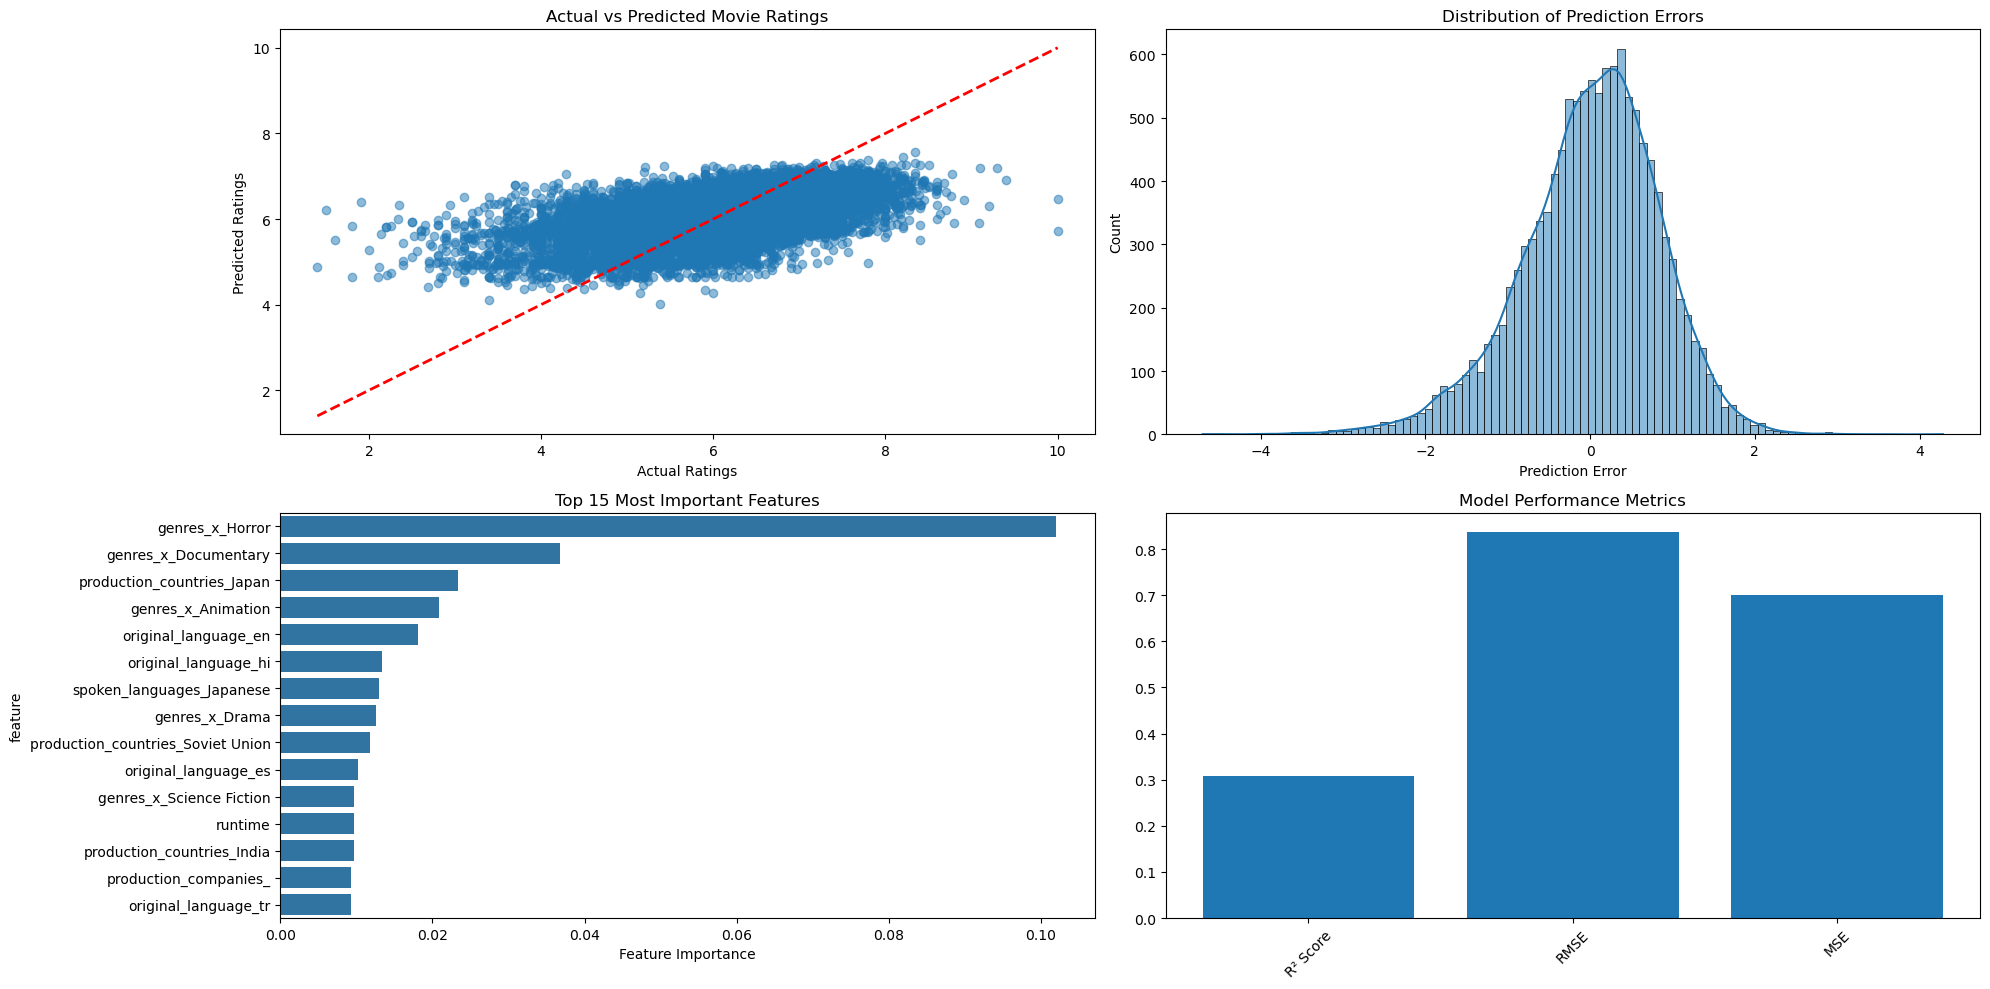


Detailed Model Performance Metrics:
R² Score: 0.3089
RMSE: 0.8367
MSE: 0.7001


In [8]:
# Create a figure with multiple subplots
plt.figure(figsize=(20, 10))

# 1. Actual vs Predicted Values
plt.subplot(2, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Movie Ratings')

# 2. Distribution of Prediction Errors
plt.subplot(2, 2, 2)
errors = y_test - y_pred
sns.histplot(errors, kde=True)
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')

# 3. Top 15 Feature Importance Plot
plt.subplot(2, 2, 3)
top_15_features = feature_importance.head(15)
sns.barplot(x='importance', y='feature', data=top_15_features)
plt.title('Top 15 Most Important Features')
plt.xlabel('Feature Importance')

# 4. Model Performance Metrics
plt.subplot(2, 2, 4)
metrics = {
    'R² Score': r2,
    'RMSE': rmse,
    'MSE': mse
}
plt.bar(metrics.keys(), metrics.values())
plt.title('Model Performance Metrics')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print detailed metrics
print("\nDetailed Model Performance Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE: {mse:.4f}")

<Figure size 1200x800 with 0 Axes>

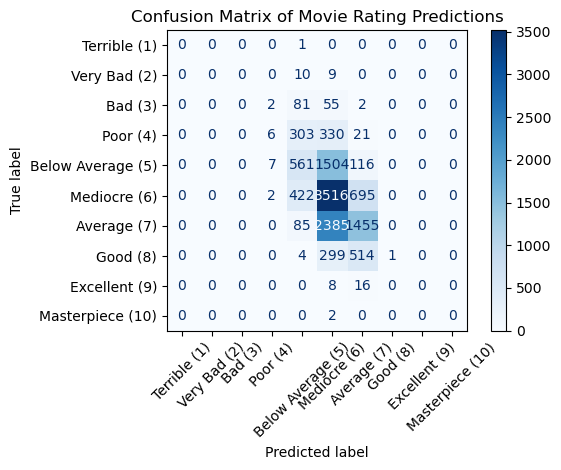


Classification Report:
                   precision    recall  f1-score   support

      Average (7)       0.52      0.37      0.43      3925
          Bad (3)       0.00      0.00      0.00       140
Below Average (5)       0.38      0.26      0.31      2188
    Excellent (9)       0.00      0.00      0.00        24
         Good (8)       1.00      0.00      0.00       818
 Masterpiece (10)       0.00      0.00      0.00         2
     Mediocre (6)       0.43      0.76      0.55      4635
         Poor (4)       0.35      0.01      0.02       660
     Terrible (1)       0.00      0.00      0.00         1
     Very Bad (2)       0.00      0.00      0.00        19

         accuracy                           0.45     12412
        macro avg       0.27      0.14      0.13     12412
     weighted avg       0.48      0.45      0.40     12412



c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [9]:
# Create rating categories
def categorize_rating(rating):
    if rating < 1.5:
        return 'Terrible (1)'
    elif rating < 2.5:
        return 'Very Bad (2)'
    elif rating < 3.5:
        return 'Bad (3)'
    elif rating < 4.5:
        return 'Poor (4)'
    elif rating < 5.5:
        return 'Below Average (5)'
    elif rating < 6.5:
        return 'Mediocre (6)'
    elif rating < 7.5:
        return 'Average (7)'
    elif rating < 8.5:
        return 'Good (8)'
    elif rating < 9.5:
        return 'Excellent (9)'
    else:
        return 'Masterpiece (10)'

# Create ordered categories
labels = ['Terrible (1)', 'Very Bad (2)', 'Bad (3)', 'Poor (4)',
          'Below Average (5)', 'Mediocre (6)', 'Average (7)', 
          'Good (8)', 'Excellent (9)', 'Masterpiece (10)']
existing_categories = pd.CategoricalDtype(categories=labels, ordered=True)

# Bin the actual and predicted values
y_test_binned = pd.Series(y_test.apply(categorize_rating), dtype=existing_categories)
y_pred_binned = pd.Categorical([categorize_rating(pred) for pred in y_pred], dtype=existing_categories)

# Create confusion matrix
cm = confusion_matrix(y_test_binned, y_pred_binned, labels=labels)

# Plot confusion matrix
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.xticks(rotation=45)
plt.title('Confusion Matrix of Movie Rating Predictions')
plt.tight_layout()
plt.show()

# Calculate and print classification metrics
print("\nClassification Report:")
print(classification_report(y_test_binned, y_pred_binned))

Num GPUs Available:  0


c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 8.9950 - mae: 2.1751 - mse: 8.9950 - val_loss: 0.9696 - val_mae: 0.7790 - val_mse: 0.9696
Epoch 2/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 1.1889 - mae: 0.8598 - mse: 1.1889 - val_loss: 0.9291 - val_mae: 0.7539 - val_mse: 0.9291
Epoch 3/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.9230 - mae: 0.7573 - mse: 0.9230 - val_loss: 0.9355 - val_mae: 0.7643 - val_mse: 0.9355
Epoch 4/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.7925 - mae: 0.7016 - mse: 0.7925 - val_loss: 0.9266 - val_mae: 0.7596 - val_mse: 0.9266
Epoch 5/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.6948 - mae: 0.6519 - mse: 0.6948 - val_loss: 0.8836 - val_mae: 0.7361 - val_mse: 0.8836
Epoch 6/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.6223 - mae: 0.6152 - mse: 0.6223 - val_loss: 0.9212 - val_mae: 0.7558 - val_mse: 0.9212
Epoch 7/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.5606 - mae: 0.579

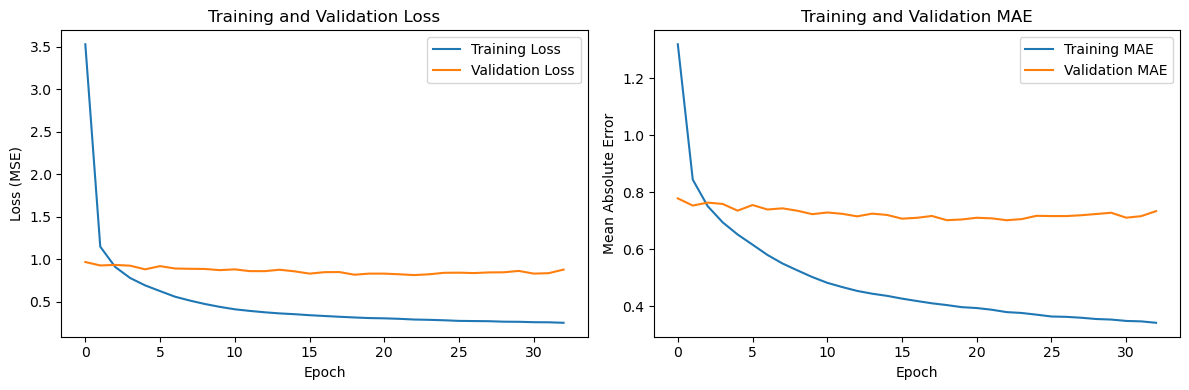

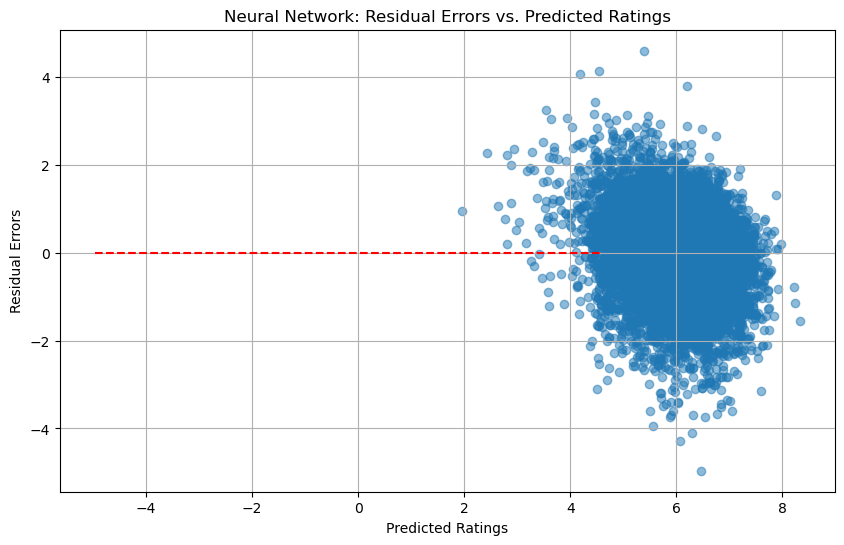


Neural Network Metrics:
R² Score: 0.2004
RMSE: 0.9000
MSE: 0.8100

Model Comparison:
            Model      RMSE       MSE        R²
0         XGBoost  0.836709  0.700082  0.308880
1  Neural Network  0.899979  0.809962  0.200406


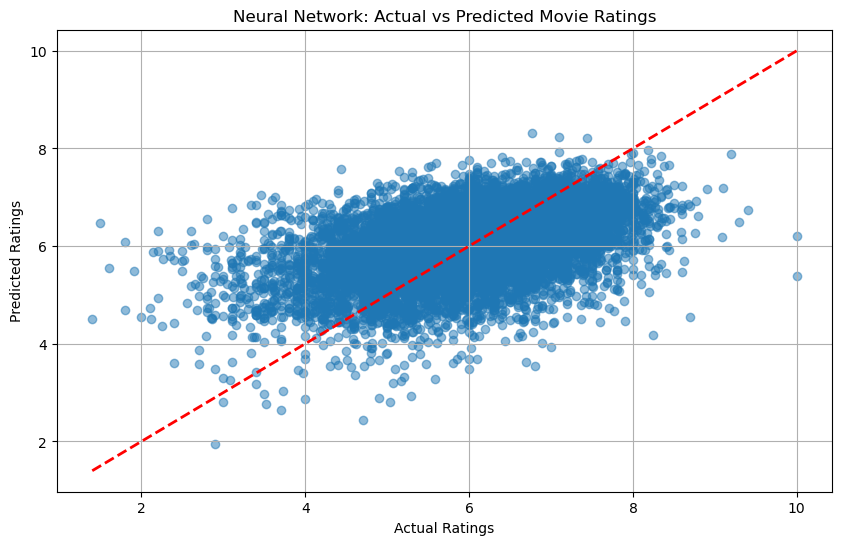

In [10]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Use the same X_train, X_test, y_train, y_test from previous cells

# Standardize the features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build neural network model
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # No activation for regression
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
nn_mse, nn_mae, _ = model.evaluate(X_test_scaled, y_test, verbose=0)
nn_rmse = np.sqrt(nn_mse)
nn_predictions = model.predict(X_test_scaled).flatten()

# Calculate R² score
nn_r2 = r2_score(y_test, nn_predictions)

# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training and Validation MAE')
plt.tight_layout()
plt.show()
# Plot residual errors
plt.figure(figsize=(10, 6))
errors = y_test - nn_predictions
plt.scatter(nn_predictions, errors, alpha=0.5)
plt.hlines(y=0, xmin=errors.min(), xmax=errors.max(), colors='red', linestyles='--')
plt.xlabel('Predicted Ratings')
plt.ylabel('Residual Errors')
plt.title('Neural Network: Residual Errors vs. Predicted Ratings')
plt.grid(True)
plt.show()

# Print neural network model metrics
print("\nNeural Network Metrics:")
print(f"R² Score: {nn_r2:.4f}")
print(f"RMSE: {nn_rmse:.4f}")
print(f"MSE: {nn_mse:.4f}")
# Compare Neural Network with XGBoost
comparison = {
    'Model': ['XGBoost', 'Neural Network'],
    'RMSE': [rmse, nn_rmse],
    'MSE': [mse, nn_mse],
    'R²': [r2, nn_r2]
}

comparison_df = pd.DataFrame(comparison)
print("\nModel Comparison:")
print(comparison_df)


# Plot actual vs predicted for Neural Network
plt.figure(figsize=(10, 6))
plt.scatter(y_test, nn_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Neural Network: Actual vs Predicted Movie Ratings')
plt.grid(True)
plt.show()

In [11]:
# Clean uo memory
del X_train_scaled
del X_test_scaled   
del scaler
del model
del xgb_model

C:\Users\laure\AppData\Local\Temp\ipykernel_6424\2512496283.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y_test_binned, order=labels, palette='viridis')


NameError: name 'class_distribution' is not defined

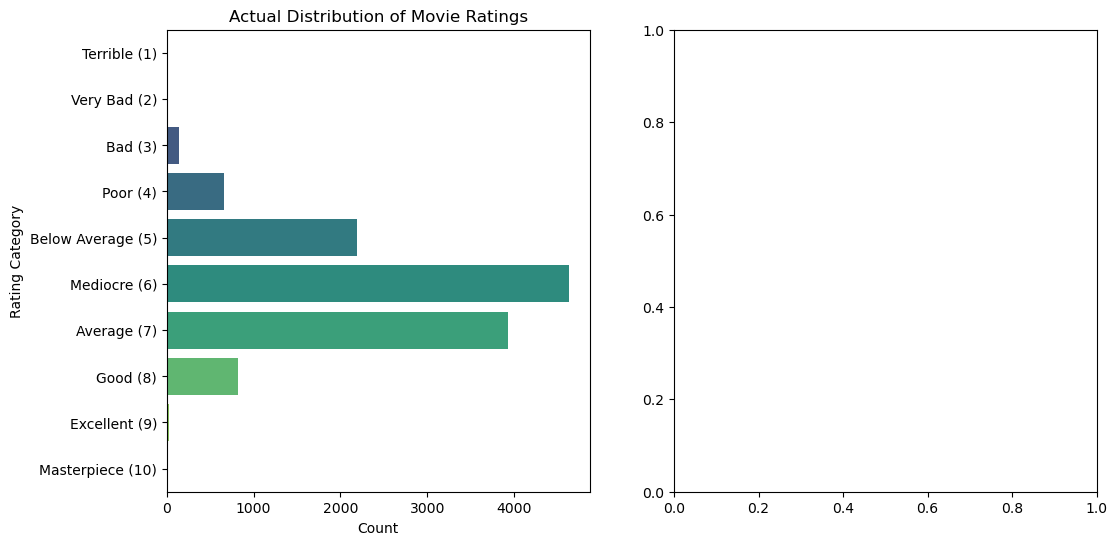

In [12]:


# Create a visualization to compare actual vs random baseline predictions
plt.figure(figsize=(12, 6))

# Actual distribution of ratings
plt.subplot(1, 2, 1)
sns.countplot(y=y_test_binned, order=labels, palette='viridis')
plt.title('Actual Distribution of Movie Ratings')
plt.xlabel('Count')
plt.ylabel('Rating Category')

# Random distribution (what we'd expect if guessing at random)
plt.subplot(1, 2, 2)
random_probs = {cat: class_distribution[cat] / len(y_test_binned) for cat in labels}
bars = plt.barh(labels, [random_probs[cat] for cat in labels], color='skyblue')
plt.title('Random Baseline Probability')
plt.xlabel('Probability')
plt.ylabel('Rating Category')
plt.xlim(0, 0.5)
for i, v in enumerate([random_probs[cat] for cat in labels]):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

# Create comparison of model accuracies
model_names = ['Random Baseline', 'Naive (Most Common)', 'XGBoost']
accuracies = [1/len(labels), naive_accuracy, xgb_accuracy]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['lightgray', 'skyblue', 'green'])
plt.ylabel('Accuracy')
plt.title('Movie Rating Classification: Model Comparison')
plt.ylim(0, 0.5)  # Set y-axis limit to focus on the differences

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
# Implement a naive classifier that always predicts the most common class

# First, let's see the distribution of rating categories in our test set
class_distribution = Counter(y_test_binned)
print("Class distribution in test set:")
for category, count in class_distribution.most_common():
    print(f"{category}: {count} ({count/len(y_test_binned)*100:.2f}%)")

# Find the most common class
most_common_class = class_distribution.most_common(1)[0][0]
print(f"\nMost common class: {most_common_class}")

# Create naive predictions (always predict the most common class)
naive_predictions = np.array([most_common_class] * len(y_test_binned))

# Calculate the accuracy of the naive classifier
naive_accuracy = (naive_predictions == y_test_binned).mean()
print(f"Naive classifier accuracy: {naive_accuracy:.4f}")

# Create confusion matrix for naive classifier
naive_cm = confusion_matrix(y_test_binned, naive_predictions, labels=labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
naive_disp = ConfusionMatrixDisplay(confusion_matrix=naive_cm, display_labels=labels)
naive_disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Naive Classifier')
plt.tight_layout()
plt.show()

# Calculate and print classification metrics
print("\nClassification Report - Naive Classifier:")
print(classification_report(y_test_binned, naive_predictions))

# Compare with XGBoost and Neural Network models
print("\nModel Comparison:")
xgb_accuracy = (y_pred_binned == y_test_binned).mean()
print(f"Naive Classifier Accuracy: {naive_accuracy:.4f}")
print(f"XGBoost Model Accuracy: {xgb_accuracy:.4f}")
print(f"Improvement over naive baseline: {(xgb_accuracy - naive_accuracy) / naive_accuracy * 100:.2f}%")

In [ ]:

# Initialize SHAP (especially for JavaScript plots in notebooks)
shap.initjs()

# --- 1. Re-train XGBoost Model ---
print("Re-training XGBoost model...")
xgb_model_shap = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgb_model_shap.fit(X_train, y_train)
print("XGBoost model re-trained.")

# --- 2. XGBoost SHAP Analysis ---
print("\nCalculating SHAP values for XGBoost model...")
# Using TreeExplainer for tree-based models like XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model_shap)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Plot SHAP summary for XGBoost
print("Plotting SHAP summary for XGBoost...")
plt.figure() # Create a new figure to avoid overlap if previous plots were not cleared
shap.summary_plot(shap_values_xgb, X_test, show=False)
plt.title("SHAP Summary Plot - XGBoost Model")
plt.show()

print("\nSHAP analysis complete.")

# Clean up re-trained models if no longer needed to save memory
del xgb_model_shap